<a href="https://colab.research.google.com/github/bachelormuthu10-hash/project/blob/main/food_delivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- DATASET PREVIEW (FIRST 5 ROWS) ---
   Order_ID           Timestamp                  Location  \
0     10001 2026-06-01 00:00:00          Zone C (IT Park)   
1     10002 2026-06-01 00:17:00  Zone D (University Area)   
2     10003 2026-06-01 00:34:00         Zone A (Downtown)   
3     10004 2026-06-01 00:51:00          Zone C (IT Park)   
4     10005 2026-06-01 01:08:00          Zone C (IT Park)   

           Item_Ordered  Price  Order_Hour  
0        Burger & Fries    280           0  
1        Burger & Fries    120           0  
2      Margherita Pizza    210           0  
3  Paneer Butter Masala     60           0  
4        Burger & Fries     60           1   



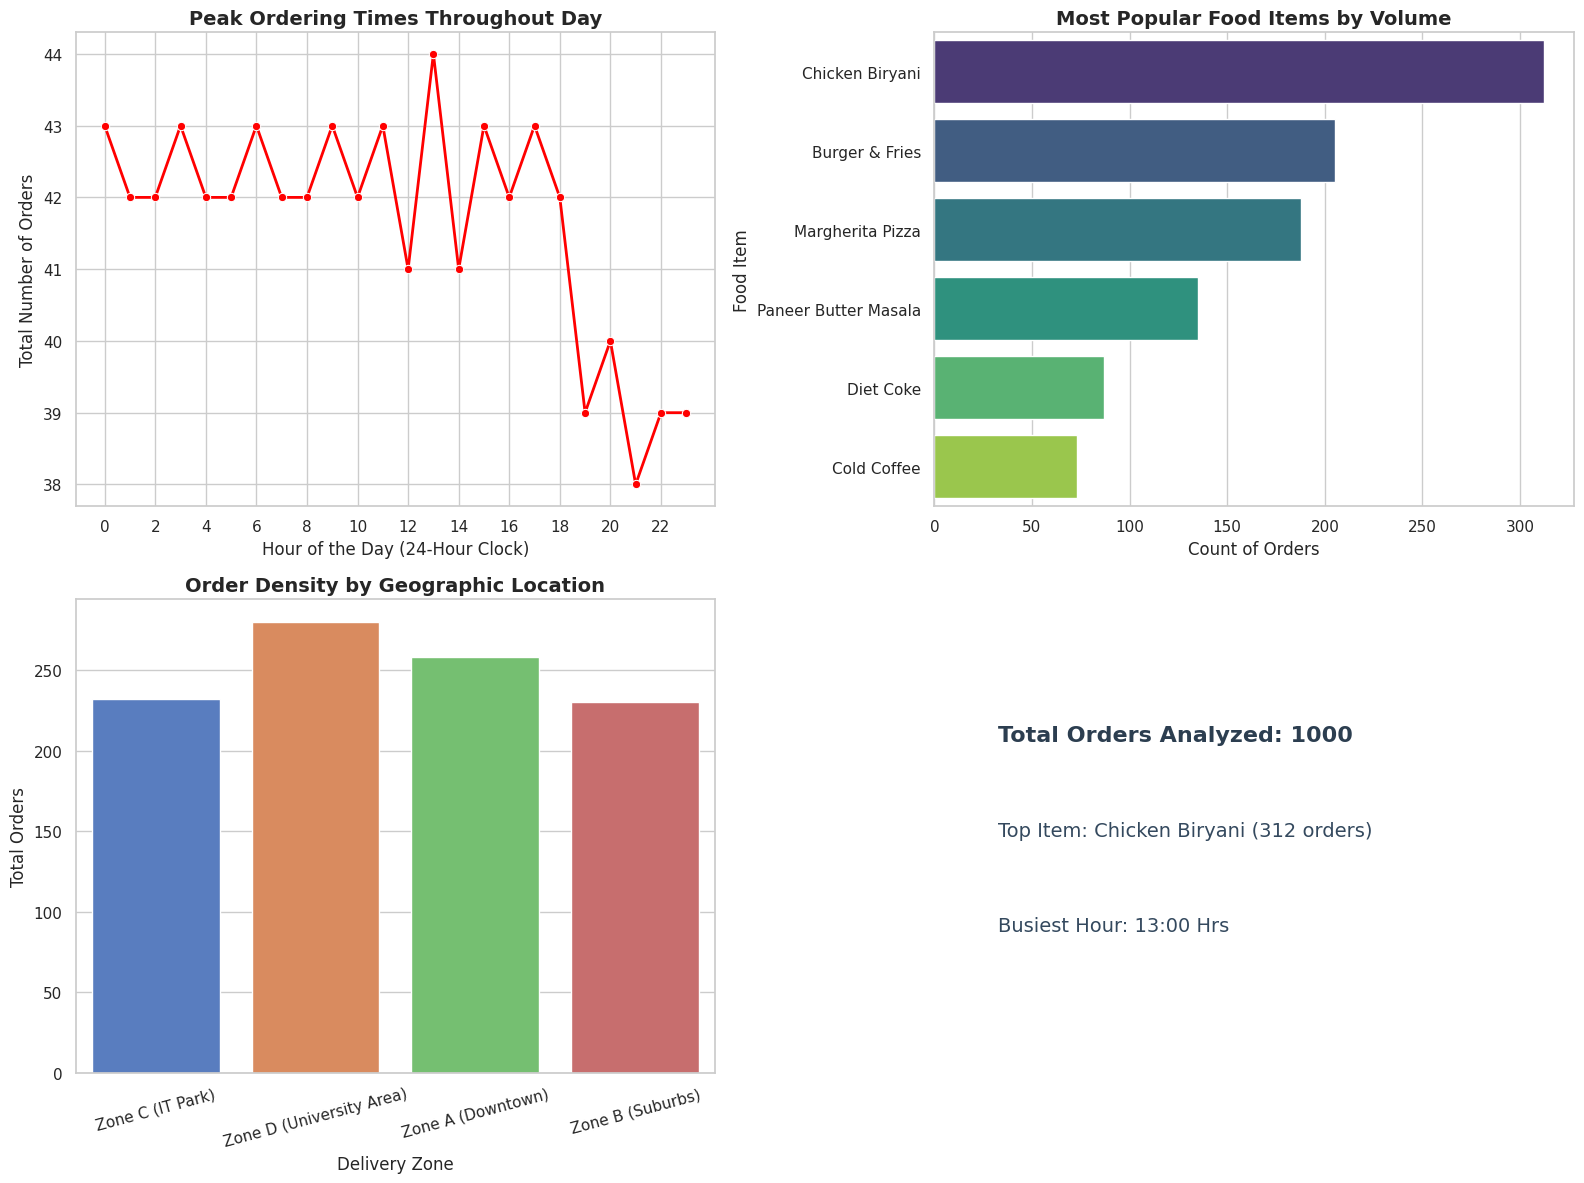

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================================
# STEP 1: GENERATE MOCK FOOD DELIVERY DATASET
# ==========================================================
np.random.seed(42)
n_orders = 1000

# Mock arrays
items = ['Chicken Biryani', 'Margherita Pizza', 'Burger & Fries', 'Paneer Butter Masala', 'Diet Coke', 'Cold Coffee']
locations = ['Zone A (Downtown)', 'Zone B (Suburbs)', 'Zone C (IT Park)', 'Zone D (University Area)']

# Creating raw mock data (Simulating a real CSV file structure)
raw_data = {
    'Order_ID': range(10001, 10001 + n_orders),
    'Timestamp': pd.date_range(start='2026-06-01 00:00:00', periods=n_orders, freq='17min'), # Real timestamps
    'Location': np.random.choice(locations, size=n_orders),
    'Item_Ordered': np.random.choice(items, size=n_orders, p=[0.30, 0.20, 0.20, 0.15, 0.08, 0.07]),
    'Price': np.random.choice([250, 280, 150, 210, 60, 120], size=n_orders)
}

# Load into DataFrame
df = pd.DataFrame(raw_data)

# ==========================================================
# STEP 2: DATA CLEANING & PREPROCESSING
# ==========================================================
# Convert Timestamp column to standard datetime object
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract the Hour of the day for peak-time analysis
df['Order_Hour'] = df['Timestamp'].dt.hour

print("--- DATASET PREVIEW (FIRST 5 ROWS) ---")
print(df.head(), "\n")

# ==========================================================
# STEP 3: DATA ANALYSIS & FILTERING
# ==========================================================
# Task 1: Find Most Popular Dishes
popular_dishes = df['Item_Ordered'].value_counts()

# Task 2: Identify Peak Order Hours
peak_hours = df['Order_Hour'].value_counts().sort_index()

# ==========================================================
# STEP 4: DATA VISUALIZATION (DASHBOARD)
# ==========================================================
# Set up a clean dashboard style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Line plot for Peak Ordering Times
sns.lineplot(x=peak_hours.index, y=peak_hours.values, marker='o', color='red', ax=axes[0, 0], linewidth=2)
axes[0, 0].set_title('Peak Ordering Times Throughout Day', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hour of the Day (24-Hour Clock)')
axes[0, 0].set_ylabel('Total Number of Orders')
axes[0, 0].set_xticks(range(0, 24, 2))

# Chart 2: Bar plot for Popular Dishes
sns.barplot(x=popular_dishes.values, y=popular_dishes.index, hue=popular_dishes.index, palette='viridis', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Most Popular Food Items by Volume', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Count of Orders')
axes[0, 1].set_ylabel('Food Item')

# Chart 3: Count plot for Sales across Location Zones
sns.countplot(data=df, x='Location', hue='Location', palette='muted', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Order Density by Geographic Location', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Delivery Zone')
axes[1, 0].set_ylabel('Total Orders')
axes[1, 0].tick_params(axis='x', rotation=15)

# Chart 4: Simple summary matrix box (KPI Panel)
axes[1, 1].axis('off') # Hide axes for text panel
total_sales = (df['Price']).sum()
axes[1, 1].text(0.1, 0.7, f"Total Orders Analyzed: {n_orders}", fontsize=16, fontweight='bold', color='#2c3e50')
axes[1, 1].text(0.1, 0.5, f"Top Item: {popular_dishes.index[0]} ({popular_dishes.values[0]} orders)", fontsize=14, color='#34495e')
axes[1, 1].text(0.1, 0.3, f"Busiest Hour: {peak_hours.idxmax()}:00 Hrs", fontsize=14, color='#34495e')

# Final adjustments and rendering
plt.tight_layout()
plt.show()
